In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 500

data = {
    "years_experience": np.random.randint(0, 15, n),
    "num_languages": np.random.randint(1, 10, n),
    "avg_commits_per_week": np.random.randint(1, 50, n),
    "bugs_fixed_per_month": np.random.randint(0, 40, n),
    "projects_completed": np.random.randint(0, 20, n),
    "code_quality_score": np.random.randint(50, 100, n),
}

df = pd.DataFrame(data)

# Target variable: "high_performer" (1 = yes, 0 = no)
df["high_performer"] = (
    (df["years_experience"] > 5) &
    (df["code_quality_score"] > 75) &
    (df["bugs_fixed_per_month"] > 10)
).astype(int)

# Save dataset
df.to_csv("developers.csv", index=False)

df.head()

,years_experience,num_languages,avg_commits_per_week,bugs_fixed_per_month,projects_completed,code_quality_score,high_performer
0,6,2,11,12,17,89,1
1,3,9,9,17,17,67,0
2,12,8,34,32,16,58,0
3,14,7,12,15,7,74,0
4,10,9,35,1,14,89,0


In [2]:
from sklearn.model_selection import train_test_split

df = pd.read_csv("developers.csv")

X = df.drop("high_performer", axis=1)
y = df["high_performer"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        76
           1       1.00      1.00      1.00        24

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [4]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=7,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        76
           1       1.00      1.00      1.00        24

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



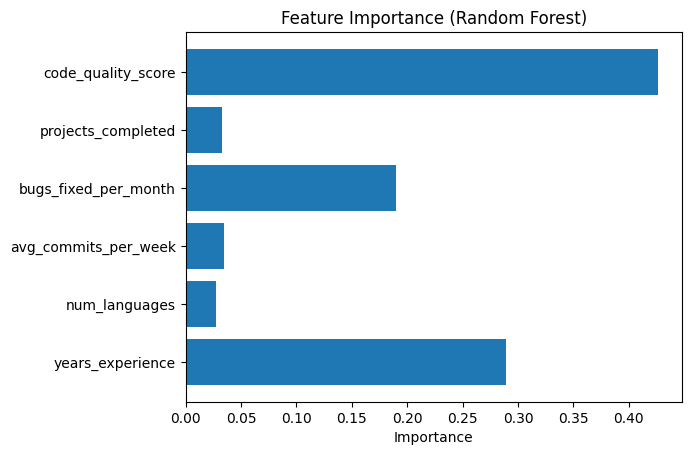

In [5]:
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.show()